In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

In [132]:
data = []
header = []
for i in range(1,6):
    with fits.open(f"M13_000{i}.fits") as hdul:
        header_ = hdul[0].header
        data_ = hdul[0].data
        header.append(header_)
        data.append(data_)
print(data[1][0])

[494 529 549 ... 492 535 560]


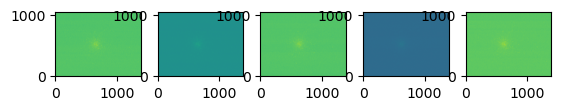

In [82]:
fig, axes = plt.subplots(1,5)
for i in range(0,5):
    axes[i].imshow(data[i], origin = "lower")                

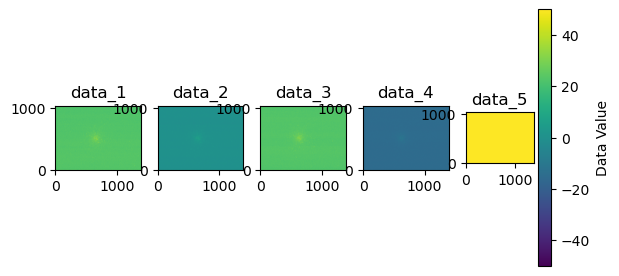

In [215]:
fig, axes = plt.subplots(1,5)
for i in range(0,5):
    axes[i].imshow(data[i], origin = "lower")
    im = plt.imshow(data[i], vmin = -50, vmax = 50, origin = "lower")
    axes[i].set_title(f"data_{i+1}")
cbar = fig.colorbar(im, label = 'Data Value')
plt.show()
# The first four graphs display a relativley similar color to the original plotting, while the fifth graph is shown in the higher region of light.

data_1: Median: 512.0 Mean: 510.4706668600796
data_2: Median: 511.0 Mean: 509.7460150033157
data_3: Median: 510.0 Mean: 508.0498729000884
data_4: Median: 509.0 Mean: 507.90583554376656
data_5: Median: 510.0 Mean: 508.7919920148099


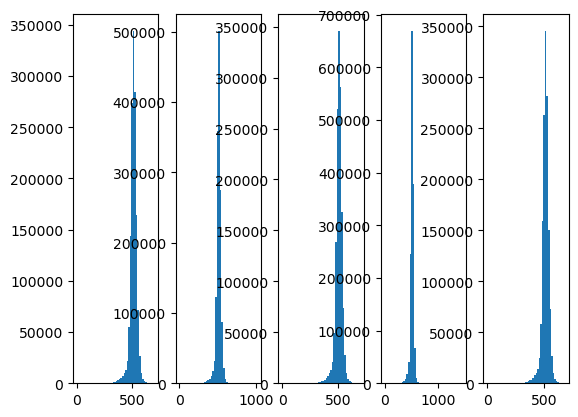

In [138]:
fig, axes = plt.subplots(1,5)
for i in range(0,5):
    axes[i].hist(data[i].ravel(),bins=50)
    median_arr = np.median(data[i])
    mean_arr = np.mean(data[i])
    print(f"data_{i+1}: Median: {median_arr} Mean: {mean_arr}")

In [139]:
# The x-axis is the values present in the data file, the y axis is the frequency of a specific value.
# bin = 50 indicates there are 50 subgroups on the x-axis, where valeus between the min and max x-axis values were divided into 50 equal bins for the data to fall into.
# The data is largley centered around 500, with the heighest frequencys being found across the data sets at 500.
# The majority of the data is largley compact around the peak and not siginficatly spread out.
# The median is within 509 - 512 , with the mean ranging from 507-510.5.

Text(0.5, 1.0, 'Combined File histogram')

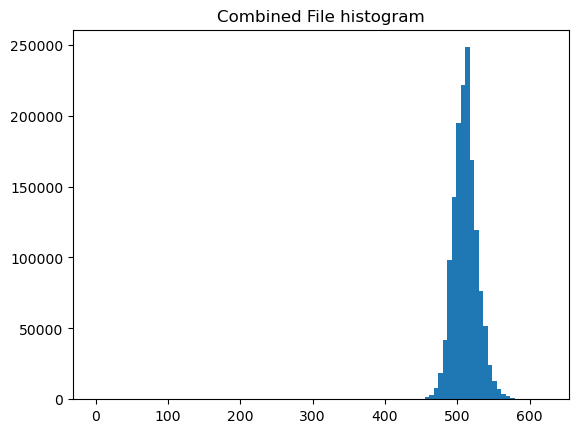

In [209]:
median_axis_0 = np.median(data,axis = 0)
plt.hist(median_axis_0.ravel(), bins = 100)
plt.title("Combined File histogram")


Text(0.5, 1.0, 'Combined File')

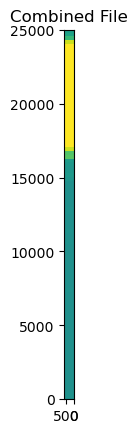

In [211]:
median_axis_0 = np.median(data,axis = 0)
counts, bin_edges = np.histogram(median_axis_0.ravel(), bins = 100)
histor_im = counts.reshape(-1,1)
plt.imshow(histor_im, vmin = -50, vmax = 50, extent = [bin_edges[-1],bin_edges[0],0,25000], origin = "lower")
plt.title("Combined File")